# Task 08: Neural Network Basics with Keras

## Project: Client Retention Prediction Using Artificial Neural Networks

This project uses TensorFlow and Keras to build an Artificial Neural Network (ANN) for predicting client retention. Customer data is preprocessed and used to train a deep learning model that identifies whether clients are likely to stay or leave. The model's performance is evaluated and compared with traditional machine learning model to analyze the effectiveness of deep learning approaches, while accuracy and loss curves are used to visualize the learning process and generate business insights.


### Import Required Libraries

The following libraries are used for data manipulation, visualization, machine learning, and deep learning model development.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### Dataset Loading

The client retention dataset is loaded into a Pandas DataFrame for exploration and preprocessing.

In [4]:
df = pd.read_csv("coretech_client_retention.csv")

df.head()

,Client_ID,Monthly_Spend,Support_Tickets,Contract_Length,Service_Usage,Customer_Satisfaction,Renewal_History,Client_Status
0,2001,960,12,4,76,78,0,At_Risk
1,2002,3872,19,25,96,70,2,At_Risk
2,2003,3192,14,3,21,57,0,Churned
3,2004,566,2,32,29,75,3,At_Risk
4,2005,4526,7,3,14,41,1,Churned


## Dataset Overview
### Exploratory Data Analysis

Before building the neural network, it is important to understand the dataset structure, feature types, and statistical information.

In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client_ID              350 non-null    int64 
 1   Monthly_Spend          350 non-null    int64 
 2   Support_Tickets        350 non-null    int64 
 3   Contract_Length        350 non-null    int64 
 4   Service_Usage          350 non-null    int64 
 5   Customer_Satisfaction  350 non-null    int64 
 6   Renewal_History        350 non-null    int64 
 7   Client_Status          350 non-null    object
dtypes: int64(7), object(1)
memory usage: 22.0+ KB


,Client_ID,Monthly_Spend,Support_Tickets,Contract_Length,Service_Usage,Customer_Satisfaction,Renewal_History
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,2175.500000,2603.845714,9.502857,17.868571,54.151429,68.765714,1.991429
std,101.180532,1389.773414,5.921041,10.385679,25.543321,16.971474,1.441281
min,2001.000000,104.000000,0.000000,1.000000,10.000000,40.000000,0.000000
25%,2088.250000,1393.250000,4.000000,8.000000,33.250000,54.000000,1.000000
50%,2175.500000,2712.500000,10.000000,19.000000,53.000000,68.000000,2.000000
75%,2262.750000,3715.750000,15.000000,27.000000,74.750000,83.000000,3.000000
max,2350.000000,4993.000000,19.000000,35.000000,99.000000,99.000000,4.000000


## Target Class Distribution
### Client Status Distribution

Understanding the distribution of target classes helps identify whether the dataset is balanced and provides insight into customer retention trends.

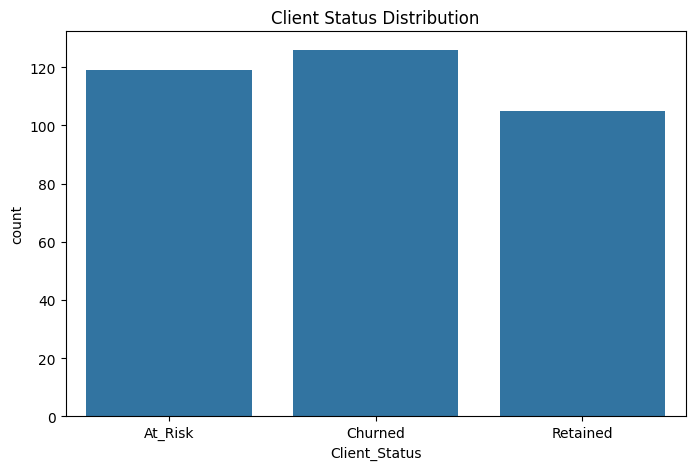

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Client_Status"
)

plt.title("Client Status Distribution")

plt.savefig(
    "client_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Selection

Relevant business-related features are selected to predict client retention status.

In [7]:
X = df[
    [
        "Monthly_Spend",
        "Support_Tickets",
        "Contract_Length",
        "Service_Usage",
        "Customer_Satisfaction",
        "Renewal_History"
    ]
]

## Label Encoding
### Target Variable Encoding

Machine learning models require numerical labels. Therefore, the Client_Status categories are converted into numerical values using Label Encoding.

In [8]:
encoder = LabelEncoder()

y = encoder.fit_transform(
    df["Client_Status"]
)

y

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 2, 0, 2, 2, 1, 0, 0, 0, 2,
       0, 2, 0, 2, 1, 1, 0, 1, 1, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 2, 2, 1, 2, 1, 2, 0, 1, 0,
       2, 0, 2, 1, 1, 0, 1, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 0, 2, 0, 0, 1,
       1, 0, 1, 2, 0, 1, 2, 0, 0, 1, 2, 0, 1, 2, 1, 1, 0, 1, 0, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 0, 1, 0, 0,
       2, 0, 0, 1, 1, 1, 2, 1, 0, 1, 2, 2, 0, 1, 0, 2, 1, 1, 0, 2, 2, 2,
       1, 1, 0, 2, 2, 0, 2, 2, 1, 1, 2, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 0,
       2, 2, 2, 0, 2, 2, 2, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 2, 2, 0, 0,
       0, 1, 2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 0, 2, 1, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 1, 0, 0, 2, 2, 0, 1, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 0,
       1, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 1, 1, 2, 1, 1, 1, 1, 0,
       0, 0, 2, 2, 1, 1, 1, 2, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 1,
       2, 2, 2, 1, 1, 1, 2, 1, 0, 1, 1, 0, 2, 2, 2,

## Feature Scaling
### Data Standardization

Feature scaling ensures that all numerical variables contribute equally during model training and improves neural network convergence.

In [9]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

## Train-Test Split
The dataset is divided into training and testing subsets to evaluate model performance on unseen data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

## ANN Development
### Artificial Neural Network Architecture

A deep neural network is developed using multiple hidden layers and ReLU activation functions to learn complex customer behavior patterns.

In [11]:
model = Sequential()

model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(6,)
    )
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(
        3,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Compilation

The model is compiled using the Adam optimizer and Sparse Categorical Crossentropy loss function for multi-class classification.

In [12]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

## Model Summary

The model summary provides information about layers, parameters, and architecture complexity.

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,331 (44.26 KB)

 Trainable params: 11,331 (44.26 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The neural network is trained using the training dataset while monitoring validation performance to evaluate learning behavior and generalization capability.


In [14]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=16
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4643 - loss: 1.0470 - val_accuracy: 0.7143 - val_loss: 0.9580
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7679 - loss: 0.8751 - val_accuracy: 0.7500 - val_loss: 0.7495
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8259 - loss: 0.6629 - val_accuracy: 0.9107 - val_loss: 0.5283
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8795 - loss: 0.4688 - val_accuracy: 0.9107 - val_loss: 0.3610
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9286 - loss: 0.3293 - val_accuracy: 0.9286 - val_loss: 0.2524
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9375 - loss: 0.2466 - val_accuracy: 0.9464 - val_loss: 0.1914
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9420 - loss: 0.1919 - val_accuracy: 0.9464 - val_loss: 0.1601
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9464 - loss: 0.1539 - val_accuracy: 0.9643 - val_los

## Accuracy Curve
### Training and Validation Accuracy Analysis

The accuracy curve shows how prediction performance improves throughout the training process.

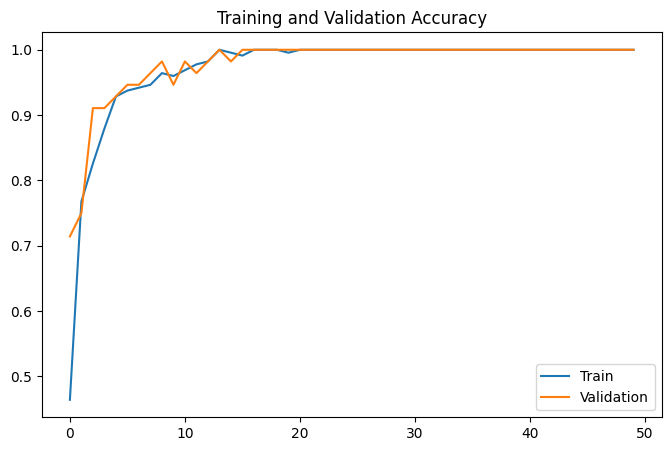

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title(
    "Training and Validation Accuracy"
)

plt.legend(
    ['Train','Validation']
)

plt.savefig(
    "accuracy_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Loss Curve
### Training and Validation Loss Analysis

Loss measures prediction error. A decreasing loss indicates successful learning and model convergence.

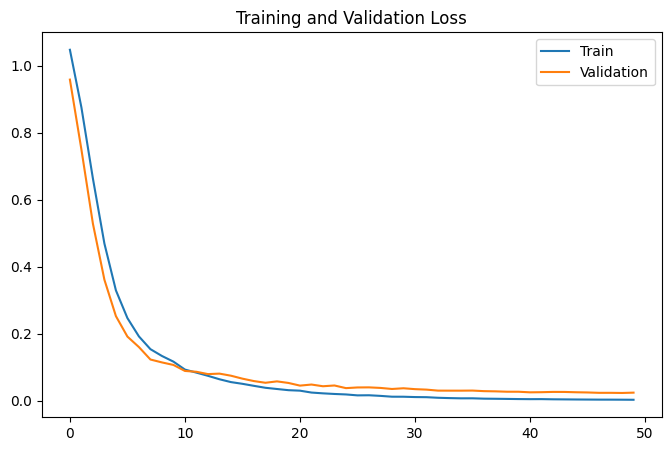

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title(
    "Training and Validation Loss"
)

plt.legend(
    ['Train','Validation']
)

plt.savefig(
    "loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Model Evaluation

After training, the neural network is evaluated on unseen test data to measure its ability to generalize beyond the training dataset.

The evaluation process provides an overall accuracy score indicating how effectively the model predicts client retention status.

In [17]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9143 - loss: 0.2586 
Test Accuracy: 0.9142857193946838
Test Loss: 0.2586408853530884


### Evaluation Interpretation

The test accuracy represents the percentage of correctly classified client records in the testing dataset.

A high accuracy score indicates that the neural network successfully learned patterns associated with customer retention behavior and can make reliable predictions on new data.

.

# Generating Predictions

The trained neural network is used to predict client retention categories for unseen test samples.

In [19]:
predictions = model.predict(X_test)

predictions = np.argmax(
    predictions,
    axis=1
)

predictions[:10]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([2, 1, 1, 1, 1, 2, 0, 2, 0, 1])

# Detailed Classification Metrics (Classification Report)

Accuracy alone is not sufficient for evaluating classification models.

The Classification Report provides Precision, Recall, and F1-Score for each client retention category, offering a more detailed assessment of model performance.

In [20]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.77      0.85        22
           1       0.83      0.95      0.89        21
           2       0.96      1.00      0.98        27

    accuracy                           0.91        70
   macro avg       0.91      0.91      0.91        70
weighted avg       0.92      0.91      0.91        70



### Classification Report Interpretation

Precision measures prediction correctness, Recall measures the ability to identify actual instances, and F1-Score provides a balanced evaluation of both.

Higher values across these metrics indicate stronger classification performance and better model reliability.

.

# Confusion Matrix

A confusion matrix provides a visual representation of correct and incorrect predictions for each retention category.

This helps identify which client categories are easiest or most difficult for the model to classify.

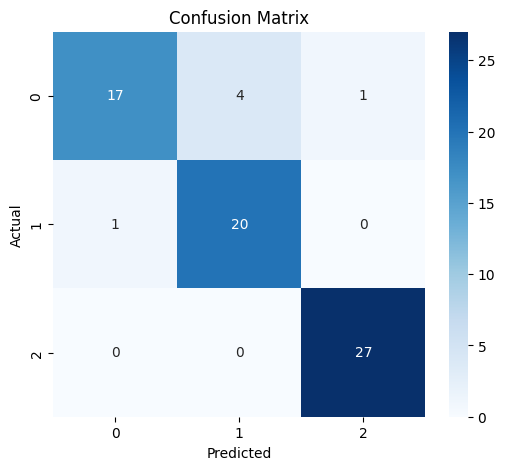

In [21]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Confusion Matrix Interpretation

Most observations concentrated along the diagonal indicate correct classifications.

Misclassifications appear outside the diagonal and highlight categories that may have similar characteristics.

Overall, the confusion matrix confirms the effectiveness of the neural network in identifying client retention patterns.

.

# Traditional Machine Learning Comparison

To evaluate the effectiveness of deep learning, Logistic Regression is used as a baseline machine learning model.

The comparison helps determine whether the Artificial Neural Network provides additional predictive benefits.

In [22]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_acc
)

Logistic Regression Accuracy: 0.9428571428571428


# Model Comparison

The performance of both models is compared using the same testing dataset.

In [23]:
comparison = pd.DataFrame({

    "Model":[
        "Artificial Neural Network",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy,
        lr_acc
    ]

})

comparison

,Model,Accuracy
0,Artificial Neural Network,0.914286
1,Logistic Regression,0.942857


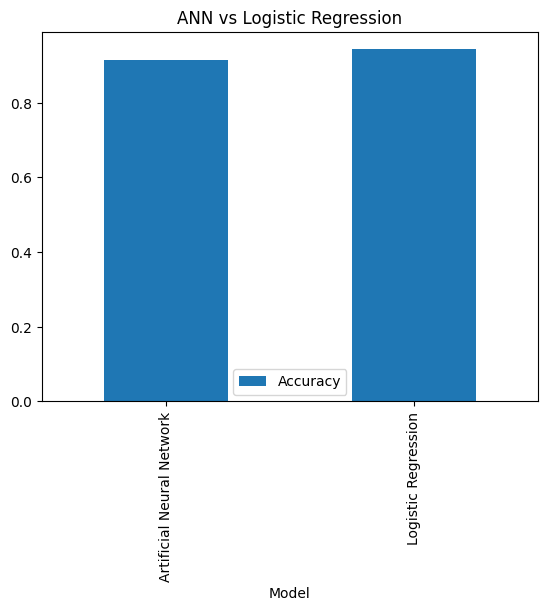

In [24]:
comparison.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title(
    "ANN vs Logistic Regression"
)

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Model Comparison Analysis

Both the Artificial Neural Network (ANN) and Logistic Regression models were trained and evaluated using the same dataset and testing procedure.

The Logistic Regression model achieved an accuracy of 94.29%, while the Artificial Neural Network achieved an accuracy of 91.43%.

Although the ANN demonstrated strong predictive performance, Logistic Regression slightly outperformed it on this dataset. This result is reasonable because the dataset contains structured numerical features and a relatively moderate number of observations, where simpler machine learning models can often perform very effectively.

The small difference in accuracy indicates that both models successfully captured important patterns related to client retention. However, Logistic Regression provided slightly better generalization performance for this particular problem.

This comparison highlights that model selection should be based on dataset characteristics and performance evaluation rather than model complexity alone. More advanced models are not always guaranteed to achieve higher accuracy.

------------------------------------------------------------------------------------------

# Business Insights

The results indicate that customer retention can be predicted effectively using machine learning techniques.

Customer satisfaction, service usage, renewal history, and contract length emerged as important factors influencing retention behavior.

While Logistic Regression achieved the highest accuracy in this project, the Artificial Neural Network also demonstrated strong predictive capability and successfully learned meaningful customer patterns.

These predictive models can help organizations identify at-risk customers, improve retention strategies, and support data-driven business decision-making.

--------------------------------------------------------------------------------------
### Download Generated Files

The following code downloads all generated visualizations for repository submission and documentation purposes.

In [26]:
from google.colab import files

files.download(
    "client_status_distribution.png"
)

files.download(
    "accuracy_curve.png"
)

files.download(
    "loss_curve.png"
)

files.download(
    "confusion_matrix.png"
)

files.download(
    "model_comparison.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
files.download(
    "coretech_client_retention.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>